# 🎯 Loss Functions in Deep Learning

**Learning Objectives:**
- Understand the role of loss functions in the training process
- Master classification losses: CrossEntropy, Binary CrossEntropy, Focal Loss
- Master regression losses: MSE, MAE, Huber (Smooth L1)
- Explore ranking and embedding losses: Triplet Loss, Contrastive Loss
- Visualize and compare loss surfaces and gradients
- Run practical PyTorch experiments comparing different losses

**Contents:**
1. Introduction: What Is a Loss Function?
2. Classification Losses
3. Regression Losses
4. Ranking and Embedding Losses (Overview)
5. Visualizing Loss Surfaces and Gradients
6. Practical Comparison: Training MLPs with Different Losses
7. Guidelines: How to Choose the Right Loss
8. Summary

## Prerequisites

We will use:
- `numpy` for calculations and visualizations.
- `matplotlib` for plotting.
- `torch` for practical deep learning experiments.
- `sklearn` for generating demo datasets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.datasets import make_moons, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

%matplotlib inline

Using device: cpu


## 1) Introduction: What Is a Loss Function?

A **loss function** (also called **cost function**, **objective function**, or **criterion**) measures how far the model's predictions are from the true targets.

The entire training process can be summarized in one line:

$$
\theta^{*} = \arg\min_{\theta} \; \mathcal{L}\bigl(f_{\theta}(X),\; Y\bigr)
$$

Where:
- $\theta$ are the model parameters (weights and biases).
- $f_{\theta}(X)$ is the model's prediction given input $X$.
- $Y$ is the ground truth (targets).
- $\mathcal{L}$ is the **loss function**.

The **optimizer** (e.g., Adam, SGD) adjusts $\theta$ to minimize $\mathcal{L}$. Therefore, the choice of loss function directly shapes **what** the model learns.

### Why It Matters

Different loss functions encode different assumptions about the problem:
- **Classification** losses handle discrete labels.
- **Regression** losses handle continuous values.
- **Ranking/embedding** losses handle relationships between samples.

Choosing the wrong loss can lead to poor convergence, sensitivity to outliers, or a model that optimizes the wrong objective.

## 2) Classification Losses

These losses are used when the output is a discrete label (e.g., cat vs. dog, digit 0–9).

### 🔹 Cross-Entropy Loss (Multi-class)

The standard loss for multi-class classification. In PyTorch: `nn.CrossEntropyLoss`.

**Formula:**
$$
\mathcal{L}_{\text{CE}} = -\sum_{c=1}^{C} y_c \log(\hat{p}_c)
$$

Where:
- $C$ is the number of classes.
- $y_c$ is 1 if the sample belongs to class $c$, 0 otherwise (one-hot encoding).
- $\hat{p}_c = \text{softmax}(z)_c = \frac{e^{z_c}}{\sum_{j=1}^{C} e^{z_j}}$ is the predicted probability for class $c$.
- $z$ are the raw logits from the model.

Since $y$ is one-hot, the formula simplifies to:
$$
\mathcal{L}_{\text{CE}} = -\log(\hat{p}_{\text{true\_class}})
$$

> **Important (PyTorch):** `nn.CrossEntropyLoss` expects **raw logits** (not probabilities). It applies `log_softmax` internally for numerical stability. Do **NOT** apply softmax before passing to this loss.

**Intuition:** The loss penalizes confident wrong predictions much more than uncertain ones. If the model assigns probability 0.01 to the true class, the loss is $-\log(0.01) \approx 4.6$. If it assigns 0.99, the loss is $-\log(0.99) \approx 0.01$.

**When to use:** Multi-class classification (e.g., image classification with 10+ classes). This is the default go-to loss for most classification problems.

In [2]:
# CrossEntropyLoss: quick demo
criterion_ce = nn.CrossEntropyLoss()

# Suppose 3 classes, batch of 2 samples
logits = torch.tensor([[2.0, 1.0, 0.1],   # model is quite confident about class 0
                        [0.5, 2.5, 0.3]])   # model is quite confident about class 1
targets = torch.tensor([0, 1])              # true labels

loss = criterion_ce(logits, targets)
print(f'CrossEntropy loss: {loss.item():.4f}')

# Let's verify manually for the first sample
probs = torch.softmax(logits[0], dim=0)
manual_loss = -torch.log(probs[0])  # loss for true class 0
print(f'Manual loss (sample 0): {manual_loss.item():.4f}')
print(f'Predicted probabilities (sample 0): {probs.detach().numpy()}')

CrossEntropy loss: 0.3185
Manual loss (sample 0): 0.4170
Predicted probabilities (sample 0): [0.6590012  0.24243298 0.09856589]


### 🔹 Binary Cross-Entropy Loss (BCE)

Used for **binary classification** (2 classes) or **multi-label classification** (each sample can have multiple labels).

**Formula (for a single sample):**
$$
\mathcal{L}_{\text{BCE}} = -\bigl[y \cdot \log(\hat{p}) + (1 - y) \cdot \log(1 - \hat{p})\bigr]
$$

Where:
- $y \in \{0, 1\}$ is the true label.
- $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$ is the predicted probability (sigmoid output).

In PyTorch:
- `nn.BCELoss` expects **probabilities** (after sigmoid).
- `nn.BCEWithLogitsLoss` expects **raw logits** (applies sigmoid internally — preferred for numerical stability).

**When to use:**
- Binary classification (spam / not spam, positive / negative).
- Multi-label classification (an image can be tagged with multiple labels simultaneously).

In [3]:
# BCEWithLogitsLoss: quick demo
criterion_bce = nn.BCEWithLogitsLoss()

# Single output per sample (binary classification)
logits_bin = torch.tensor([2.0, -1.0, 0.5])  # raw logits
targets_bin = torch.tensor([1.0, 0.0, 1.0])   # true labels

loss_bce = criterion_bce(logits_bin, targets_bin)
print(f'BCEWithLogits loss: {loss_bce.item():.4f}')

# Manual verification for the first sample
p = torch.sigmoid(logits_bin[0])
manual_bce = -(targets_bin[0] * torch.log(p) + (1 - targets_bin[0]) * torch.log(1 - p))
print(f'Manual BCE (sample 0): {manual_bce.item():.4f}')
print(f'Predicted probability (sample 0): {p.item():.4f}')

BCEWithLogits loss: 0.3048
Manual BCE (sample 0): 0.1269
Predicted probability (sample 0): 0.8808


### 🔸 Focal Loss (Handling Class Imbalance)

Introduced in the paper *"Focal Loss for Dense Object Detection"* (Lin et al., 2017), Focal Loss addresses **class imbalance** by down-weighting the loss for well-classified ("easy") examples and focusing on hard ones.

**Formula (for binary case):**
$$
\mathcal{L}_{\text{FL}} = -\alpha_t \cdot (1 - \hat{p}_t)^{\gamma} \cdot \log(\hat{p}_t)
$$

Where:
- $\hat{p}_t = \hat{p}$ if $y = 1$, else $1 - \hat{p}$.
- $\gamma \geq 0$ is the **focusing parameter**. When $\gamma = 0$, Focal Loss equals standard CE.
- $\alpha_t$ is a class-weighting factor.

**Intuition:** The $(1 - \hat{p}_t)^{\gamma}$ term acts as a modulating factor:
- If the model is **confident and correct** ($\hat{p}_t \approx 1$), this factor is close to 0 → **low loss**.
- If the model is **wrong** ($\hat{p}_t \approx 0$), this factor is close to 1 → **full loss**.

This forces the model to focus on the hard, misclassified examples instead of being overwhelmed by easy negatives.

**When to use:** Highly imbalanced datasets (e.g., object detection, medical imaging where positive examples are rare).

In [4]:
# Focal Loss implementation
class FocalLoss(nn.Module):
    """Focal Loss for binary classification (from logits)."""
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Standard BCE from logits
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        # Compute p_t
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)

        # Compute alpha_t
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Modulating factor
        focal_weight = alpha_t * (1 - p_t) ** self.gamma

        loss = focal_weight * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

# Demo: compare BCE vs Focal Loss
logits_demo = torch.tensor([3.0, 0.1, -2.0])  # confident correct, uncertain, confident wrong
targets_demo = torch.tensor([1.0, 1.0, 1.0])   # all positive

bce = F.binary_cross_entropy_with_logits(logits_demo, targets_demo, reduction='none')
focal = FocalLoss(alpha=1.0, gamma=2.0, reduction='none')
fl = focal(logits_demo, targets_demo)

print('Logits:     ', logits_demo.numpy())
print('Sigmoid(z): ', torch.sigmoid(logits_demo).detach().numpy().round(4))
print(f'BCE losses:   {bce.detach().numpy().round(4)}')
print(f'Focal losses: {fl.detach().numpy().round(4)}')
print('\n→ Focal Loss heavily down-weights the easy (confident) example and keeps the hard one.')

Logits:      [ 3.   0.1 -2. ]
Sigmoid(z):  [0.9526 0.525  0.1192]
BCE losses:   [0.0486 0.6444 2.1269]
Focal losses: [1.0000e-04 1.4540e-01 1.6501e+00]

→ Focal Loss heavily down-weights the easy (confident) example and keeps the hard one.


## 3) Regression Losses

These losses are used when the output is a continuous value (e.g., predicting house prices, temperature).

### 🔹 Mean Squared Error (MSE / L2 Loss)

The most common regression loss. In PyTorch: `nn.MSELoss`.

**Formula:**
$$
\mathcal{L}_{\text{MSE}} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)^2
$$

**Properties:**
- The squared term means that **large errors are penalized much more** than small ones.
- The gradient is proportional to the error: $\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = -\frac{2}{N}(y_i - \hat{y}_i)$.
- Very **sensitive to outliers** due to the squaring.

**When to use:** Default choice for regression when outliers are not a major concern. Corresponds to maximum likelihood estimation under the assumption of Gaussian noise.

### 🔹 Mean Absolute Error (MAE / L1 Loss)

In PyTorch: `nn.L1Loss`.

**Formula:**
$$
\mathcal{L}_{\text{MAE}} = \frac{1}{N}\sum_{i=1}^{N}|y_i - \hat{y}_i|
$$

**Properties:**
- Treats all errors equally (no squaring).
- **More robust to outliers** than MSE.
- The gradient is constant ($\pm 1$), which can cause unstable training near the optimum.
- The loss is **not differentiable at 0**.

**When to use:** When outliers are present and you don't want them to dominate the loss.

### 🔸 Huber Loss / Smooth L1 Loss

The **best of both worlds**: MSE for small errors, MAE for large errors. In PyTorch: `nn.SmoothL1Loss` or `nn.HuberLoss`.

**Formula:**
$$
\mathcal{L}_{\text{Huber}}(\delta) = 
\begin{cases}
\frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\
\delta \cdot |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}
$$

Where $\delta$ (often called `beta` in PyTorch) is the transition point between quadratic and linear behavior.

**Properties:**
- Smooth and differentiable everywhere.
- Quadratic for small errors → smooth gradients near the optimum.
- Linear for large errors → robust to outliers.
- $\delta$ is a hyperparameter that controls the transition.

**When to use:** Regression with potential outliers (widely used in object detection for bounding box regression, e.g., Faster R-CNN).

In [5]:
# Quick demo: MSE vs MAE vs Huber
predictions = torch.tensor([2.5, 0.0, 2.0, 8.0])
targets_reg = torch.tensor([3.0, -0.5, 2.0, 7.0])

mse = nn.MSELoss(reduction='none')
mae = nn.L1Loss(reduction='none')
huber = nn.SmoothL1Loss(reduction='none', beta=1.0)

print('Errors (y - ŷ):    ', (targets_reg - predictions).numpy())
print(f'MSE (per sample):   {mse(predictions, targets_reg).numpy()}')
print(f'MAE (per sample):   {mae(predictions, targets_reg).numpy()}')
print(f'Huber (per sample): {huber(predictions, targets_reg).numpy()}')
print('\n→ Notice how MSE penalizes the large error (1.0) quadratically, '
      'while MAE and Huber treat it more gently.')

Errors (y - ŷ):     [ 0.5 -0.5  0.  -1. ]
MSE (per sample):   [0.25 0.25 0.   1.  ]
MAE (per sample):   [0.5 0.5 0.  1. ]
Huber (per sample): [0.125 0.125 0.    0.5  ]

→ Notice how MSE penalizes the large error (1.0) quadratically, while MAE and Huber treat it more gently.


## 4) Ranking and Embedding Losses (Overview)

These losses don't compare predictions to labels directly. Instead, they learn **relationships between samples** — which pairs should be close or far apart in the embedding space.

### 🔹 Contrastive Loss

Used in **Siamese Networks**. Takes pairs of samples and a label indicating whether they are similar ($y = 0$) or dissimilar ($y = 1$).

**Formula:**
$$
\mathcal{L}_{\text{contrastive}} = (1 - y) \cdot \frac{1}{2}d^2 + y \cdot \frac{1}{2} \max(0,\; m - d)^2
$$

Where:
- $d = \|f(x_1) - f(x_2)\|$ is the Euclidean distance between the two embeddings.
- $m$ is the **margin** (minimum distance for dissimilar pairs).

**Intuition:** Pull similar pairs together, push dissimilar pairs apart (at least by margin $m$).

### 🔹 Triplet Loss

Works with **triplets**: (anchor, positive, negative). The anchor and positive belong to the same class; the anchor and negative belong to different classes.

**Formula:**
$$
\mathcal{L}_{\text{triplet}} = \max\bigl(0,\; d(a, p) - d(a, n) + m\bigr)
$$

Where:
- $d(a, p) = \|f(a) - f(p)\|$ is the distance between anchor and positive.
- $d(a, n) = \|f(a) - f(n)\|$ is the distance between anchor and negative.
- $m$ is the margin.

In PyTorch: `nn.TripletMarginLoss`.

**Intuition:** The anchor should be closer to the positive than to the negative by at least margin $m$.

**When to use:** Face recognition, image retrieval, learning embeddings where the number of classes is very large or unknown.

In [6]:
# Triplet Loss: quick demo
triplet_loss = nn.TripletMarginLoss(margin=1.0)

# Simulate embeddings (dim=4)
anchor   = torch.tensor([[1.0, 0.0, 0.0, 0.0]])
positive = torch.tensor([[0.9, 0.1, 0.0, 0.0]])  # close to anchor
negative = torch.tensor([[0.0, 0.0, 1.0, 0.0]])  # far from anchor

loss_triplet = triplet_loss(anchor, positive, negative)
print(f'Triplet loss (easy negative): {loss_triplet.item():.4f}')

# Hard negative: closer to anchor than the positive
hard_negative = torch.tensor([[0.95, 0.05, 0.0, 0.0]])  # very close to anchor
loss_hard = triplet_loss(anchor, positive, hard_negative)
print(f'Triplet loss (hard negative): {loss_hard.item():.4f}')

print('\n→ With the easy negative, the loss is 0 (constraint already satisfied).')
print('→ With the hard negative, the loss is positive (the model must push it away).')

Triplet loss (easy negative): 0.0000
Triplet loss (hard negative): 1.0707

→ With the easy negative, the loss is 0 (constraint already satisfied).
→ With the hard negative, the loss is positive (the model must push it away).


## 5) Visualizing Loss Surfaces and Gradients

Let's visualize how different losses behave as a function of the prediction error. This helps build intuition about their sensitivity and robustness.

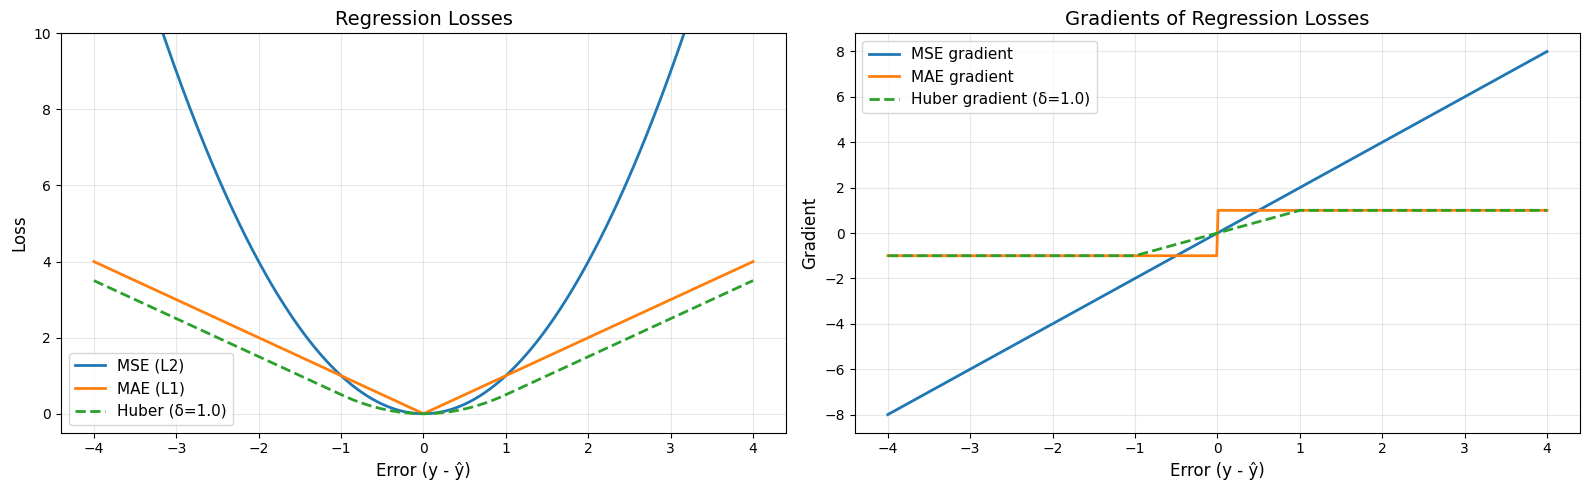

Key observations:
• MSE: gradients grow linearly with error → large errors dominate training.
• MAE: constant gradient magnitude → robust to outliers, but not smooth at 0.
• Huber: smooth near 0 (like MSE), bounded gradients far from 0 (like MAE).


In [7]:
# 5.1 — Regression losses: MSE vs MAE vs Huber
errors = np.linspace(-4, 4, 500)

mse_vals = errors ** 2
mae_vals = np.abs(errors)

delta = 1.0
huber_vals = np.where(
    np.abs(errors) <= delta,
    0.5 * errors ** 2,
    delta * np.abs(errors) - 0.5 * delta ** 2
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
axes[0].plot(errors, mse_vals, label='MSE (L2)', linewidth=2)
axes[0].plot(errors, mae_vals, label='MAE (L1)', linewidth=2)
axes[0].plot(errors, huber_vals, label=f'Huber (δ={delta})', linewidth=2, linestyle='--')
axes[0].set_xlabel('Error (y - ŷ)', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Regression Losses', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.5, 10)

# Gradient curves
mse_grad = 2 * errors             # d/d(error) of error^2
mae_grad = np.sign(errors)         # d/d(error) of |error|
huber_grad = np.where(
    np.abs(errors) <= delta,
    errors,
    delta * np.sign(errors)
)

axes[1].plot(errors, mse_grad, label='MSE gradient', linewidth=2)
axes[1].plot(errors, mae_grad, label='MAE gradient', linewidth=2)
axes[1].plot(errors, huber_grad, label=f'Huber gradient (δ={delta})', linewidth=2, linestyle='--')
axes[1].set_xlabel('Error (y - ŷ)', fontsize=12)
axes[1].set_ylabel('Gradient', fontsize=12)
axes[1].set_title('Gradients of Regression Losses', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Key observations:')
print('• MSE: gradients grow linearly with error → large errors dominate training.')
print('• MAE: constant gradient magnitude → robust to outliers, but not smooth at 0.')
print('• Huber: smooth near 0 (like MSE), bounded gradients far from 0 (like MAE).')

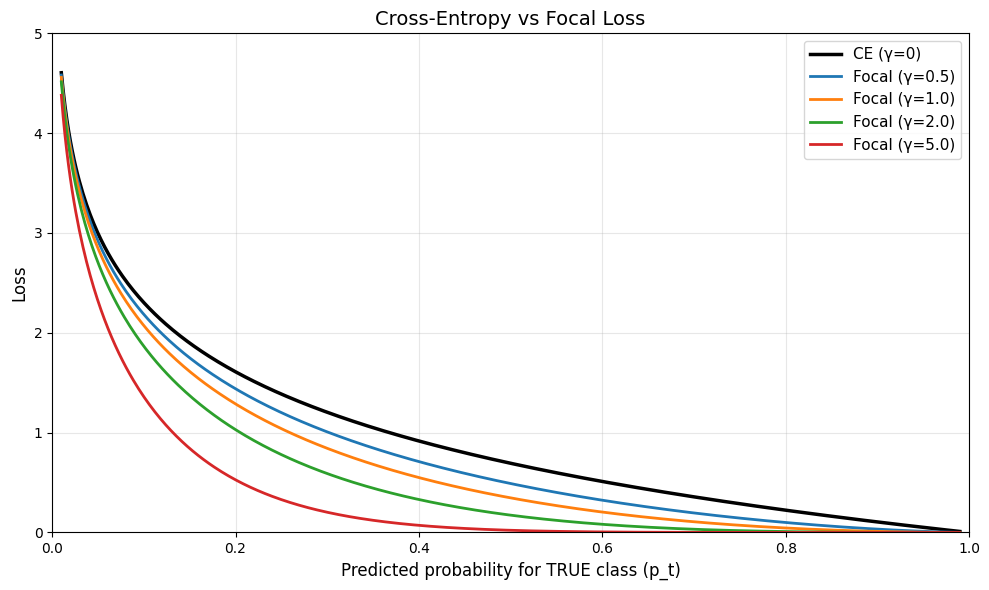

Key observations:
• When γ=0, Focal Loss = standard Cross-Entropy.
• Higher γ → well-classified examples (p_t close to 1) contribute almost zero loss.
• This lets the model focus its learning on the HARD examples.


In [8]:
# 5.2 — Classification losses: BCE vs Focal Loss (varying gamma)
p = np.linspace(0.01, 0.99, 500)  # predicted probability for the TRUE class

# Standard Cross-Entropy (= Focal with gamma=0)
ce_loss = -np.log(p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, ce_loss, label='CE (γ=0)', linewidth=2.5, color='black')

for gamma in [0.5, 1.0, 2.0, 5.0]:
    focal = -((1 - p) ** gamma) * np.log(p)
    ax.plot(p, focal, label=f'Focal (γ={gamma})', linewidth=2)

ax.set_xlabel('Predicted probability for TRUE class (p_t)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Cross-Entropy vs Focal Loss', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)

plt.tight_layout()
plt.show()

print('Key observations:')
print('• When γ=0, Focal Loss = standard Cross-Entropy.')
print('• Higher γ → well-classified examples (p_t close to 1) contribute almost zero loss.')
print('• This lets the model focus its learning on the HARD examples.')

## 6) Practical Comparison: Training MLPs with Different Losses

Let's run two experiments to see how the choice of loss function affects training.

### Experiment 1: Classification (CE vs Focal on imbalanced data)

We create an intentionally **imbalanced** binary classification dataset and compare `BCEWithLogitsLoss` (standard) vs `FocalLoss`.

In [9]:
# Generate imbalanced binary classification data
np.random.seed(42)
torch.manual_seed(42)

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

# Make it imbalanced: keep only 10% of class 1
mask_0 = y == 0
mask_1 = y == 1
n_keep = int(mask_1.sum() * 0.1)  # keep only 10% of class 1
idx_1 = np.where(mask_1)[0][:n_keep]
idx_0 = np.where(mask_0)[0]
idx = np.concatenate([idx_0, idx_1])
np.random.shuffle(idx)
X_imb, y_imb = X[idx], y[idx]

print(f'Class distribution: 0 → {(y_imb == 0).sum()}, 1 → {(y_imb == 1).sum()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.3, random_state=42, stratify=y_imb
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

Class distribution: 0 → 500, 1 → 50


In [10]:
# Simple MLP for binary classification
class BinaryMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # return raw logits


def train_binary(model, criterion, X_tr, y_tr, X_te, y_te, epochs=500, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_accs = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_tr)
        loss = criterion(logits, y_tr)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # Evaluate
        model.eval()
        with torch.no_grad():
            preds = (torch.sigmoid(model(X_te)) > 0.5).float()
            acc = (preds == y_te).float().mean().item()
            test_accs.append(acc)

    return train_losses, test_accs


# Train with BCE
torch.manual_seed(42)
model_bce = BinaryMLP().to(device)
bce_losses, bce_accs = train_binary(
    model_bce, nn.BCEWithLogitsLoss(), X_train_t, y_train_t, X_test_t, y_test_t
)

# Train with Focal Loss
torch.manual_seed(42)
model_focal = BinaryMLP().to(device)
focal_criterion = FocalLoss(alpha=0.75, gamma=2.0)  # higher alpha for minority class
focal_losses, focal_accs = train_binary(
    model_focal, focal_criterion, X_train_t, y_train_t, X_test_t, y_test_t
)

print(f'BCE final test acc:   {bce_accs[-1]:.4f}')
print(f'Focal final test acc: {focal_accs[-1]:.4f}')

BCE final test acc:   0.9576
Focal final test acc: 0.9515


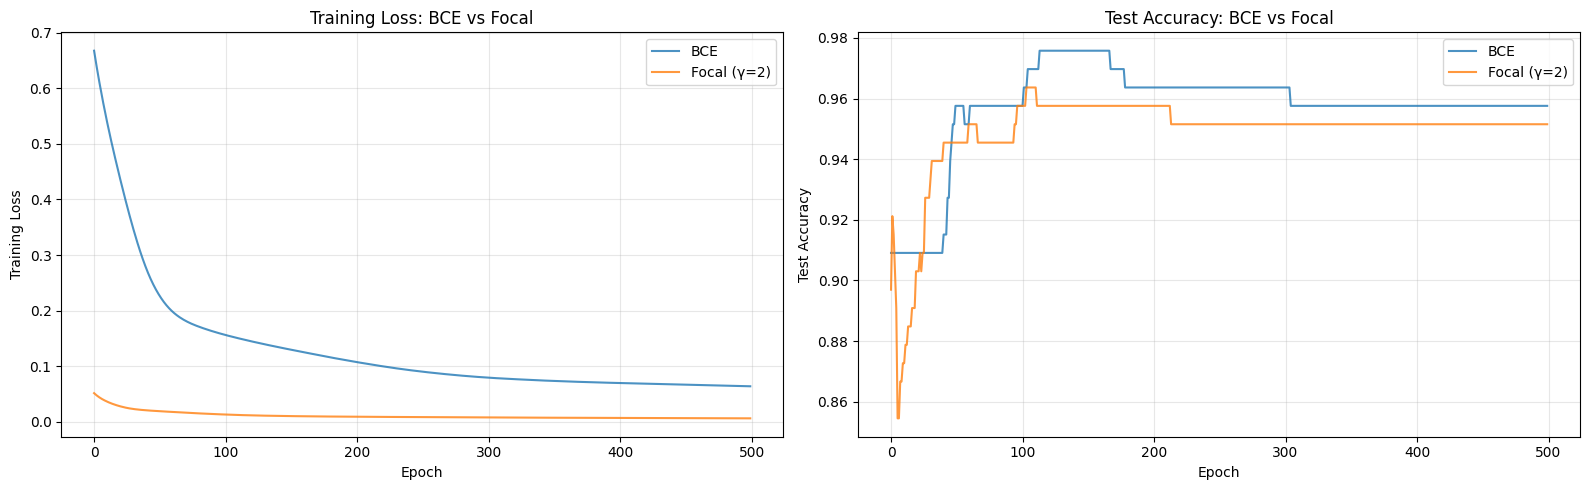

Note: on imbalanced data, Focal Loss can help the model pay more attention
to the minority class, potentially improving recall on hard examples.


In [11]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(bce_losses, label='BCE', alpha=0.8)
axes[0].plot(focal_losses, label='Focal (γ=2)', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss: BCE vs Focal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(bce_accs, label='BCE', alpha=0.8)
axes[1].plot(focal_accs, label='Focal (γ=2)', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy: BCE vs Focal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Note: on imbalanced data, Focal Loss can help the model pay more attention')
print('to the minority class, potentially improving recall on hard examples.')

### Experiment 2: Regression (MSE vs MAE vs Huber on noisy data with outliers)

We generate a regression dataset, inject outliers, and compare how each loss handles them.

In [12]:
# Generate regression data with outliers
np.random.seed(42)

X_reg, y_reg = make_regression(n_samples=300, n_features=1, noise=10.0, random_state=42)

# Inject outliers: flip some targets to extreme values
n_outliers = 15
outlier_idx = np.random.choice(len(y_reg), n_outliers, replace=False)
y_reg[outlier_idx] = y_reg[outlier_idx] + np.random.choice([-1, 1], n_outliers) * 200

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42
)

scaler_r = StandardScaler().fit(X_tr_r)
X_tr_r = scaler_r.transform(X_tr_r)
X_te_r = scaler_r.transform(X_te_r)

# Normalize targets too
y_mean, y_std = y_tr_r.mean(), y_tr_r.std()
y_tr_r_norm = (y_tr_r - y_mean) / y_std
y_te_r_norm = (y_te_r - y_mean) / y_std

X_tr_rt = torch.tensor(X_tr_r, dtype=torch.float32).to(device)
y_tr_rt = torch.tensor(y_tr_r_norm, dtype=torch.float32).to(device)
X_te_rt = torch.tensor(X_te_r, dtype=torch.float32).to(device)
y_te_rt = torch.tensor(y_te_r_norm, dtype=torch.float32).to(device)

print(f'Training samples: {len(X_tr_r)}, Test samples: {len(X_te_r)}')
print(f'Outliers injected: {n_outliers}')

Training samples: 210, Test samples: 90
Outliers injected: 15


In [13]:
# Simple MLP for regression
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_regression(model, criterion, X_tr, y_tr, X_te, y_te, epochs=500, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_tr)
        loss = criterion(preds, y_tr)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_preds = model(X_te)
            # Always evaluate with MSE for fair comparison
            test_loss = F.mse_loss(test_preds, y_te).item()
            test_losses.append(test_loss)

    return train_losses, test_losses


# Train with MSE
torch.manual_seed(42)
model_mse = RegressionMLP().to(device)
mse_train, mse_test = train_regression(
    model_mse, nn.MSELoss(), X_tr_rt, y_tr_rt, X_te_rt, y_te_rt
)

# Train with MAE
torch.manual_seed(42)
model_mae = RegressionMLP().to(device)
mae_train, mae_test = train_regression(
    model_mae, nn.L1Loss(), X_tr_rt, y_tr_rt, X_te_rt, y_te_rt
)

# Train with Huber
torch.manual_seed(42)
model_huber = RegressionMLP().to(device)
huber_train, huber_test = train_regression(
    model_huber, nn.SmoothL1Loss(beta=1.0), X_tr_rt, y_tr_rt, X_te_rt, y_te_rt
)

print(f'Final test MSE (trained with MSE):   {mse_test[-1]:.4f}')
print(f'Final test MSE (trained with MAE):   {mae_test[-1]:.4f}')
print(f'Final test MSE (trained with Huber): {huber_test[-1]:.4f}')

Final test MSE (trained with MSE):   8.3088
Final test MSE (trained with MAE):   8.3267
Final test MSE (trained with Huber): 8.3047


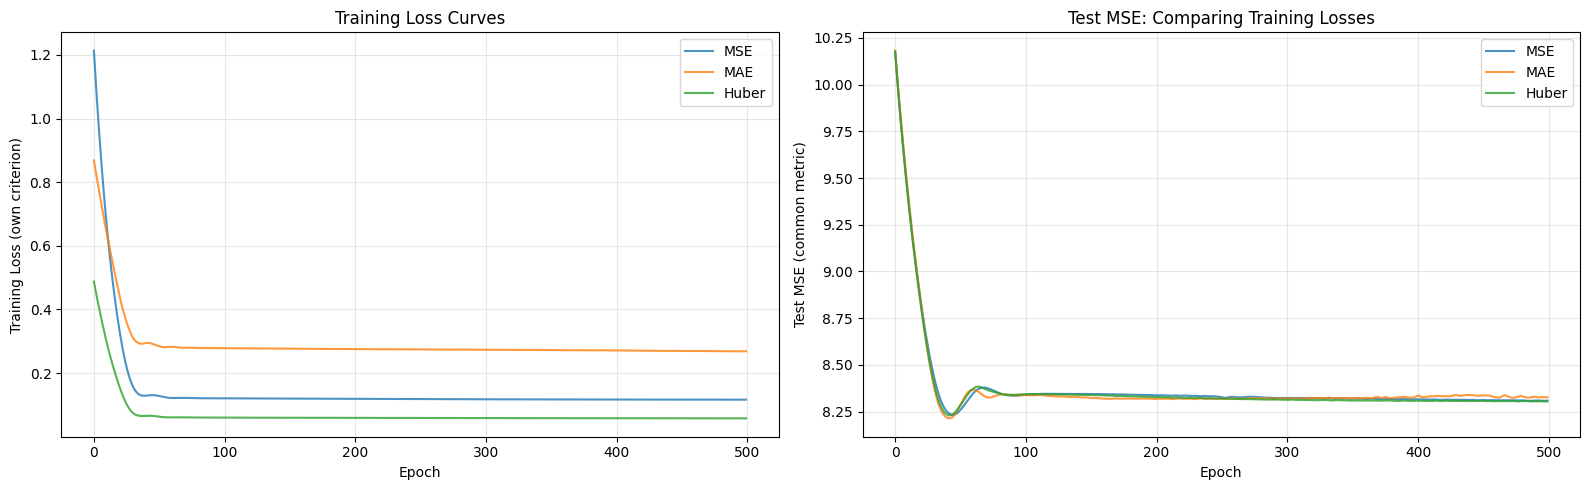

Key observations:
• MSE-trained model may overfit to outliers (outliers dominate the squared loss).
• MAE-trained model is robust to outliers but may converge less smoothly.
• Huber-trained model often achieves a good balance between the two.


In [14]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(mse_train, label='MSE', alpha=0.8)
axes[0].plot(mae_train, label='MAE', alpha=0.8)
axes[0].plot(huber_train, label='Huber', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (own criterion)')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mse_test, label='MSE', alpha=0.8)
axes[1].plot(mae_test, label='MAE', alpha=0.8)
axes[1].plot(huber_test, label='Huber', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test MSE (common metric)')
axes[1].set_title('Test MSE: Comparing Training Losses')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Key observations:')
print('• MSE-trained model may overfit to outliers (outliers dominate the squared loss).')
print('• MAE-trained model is robust to outliers but may converge less smoothly.')
print('• Huber-trained model often achieves a good balance between the two.')

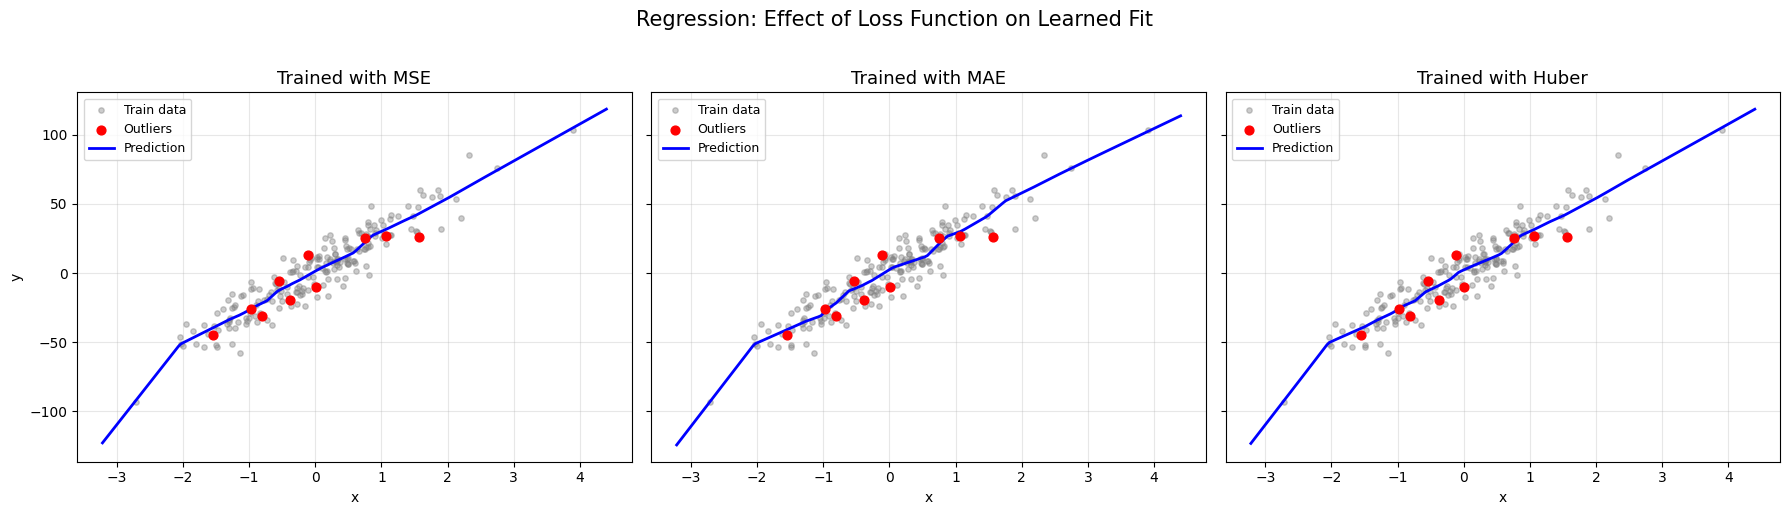

→ Observe how MSE-trained model may be pulled towards outliers,
  while MAE and Huber produce fits that are more robust to extreme values.


In [15]:
# Visualize the learned regression functions
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

x_plot = np.linspace(X_tr_r.min() - 0.5, X_tr_r.max() + 0.5, 200).reshape(-1, 1)
x_plot_t = torch.tensor(x_plot, dtype=torch.float32).to(device)

models_dict = {'MSE': model_mse, 'MAE': model_mae, 'Huber': model_huber}

for i, (name, model) in enumerate(models_dict.items()):
    model.eval()
    with torch.no_grad():
        y_pred = model(x_plot_t).cpu().numpy()

    # Denormalize for visualization
    y_pred_denorm = y_pred * y_std + y_mean
    y_train_denorm = y_tr_r_norm * y_std + y_mean

    axes[i].scatter(X_tr_r, y_train_denorm, alpha=0.4, s=15, c='gray', label='Train data')
    axes[i].scatter(X_tr_r[outlier_idx[outlier_idx < len(X_tr_r)]],
                     y_train_denorm[outlier_idx[outlier_idx < len(X_tr_r)]],
                     c='red', s=40, zorder=5, label='Outliers')
    axes[i].plot(x_plot, y_pred_denorm, linewidth=2, color='blue', label='Prediction')
    axes[i].set_title(f'Trained with {name}', fontsize=13)
    axes[i].set_xlabel('x')
    if i == 0:
        axes[i].set_ylabel('y')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Regression: Effect of Loss Function on Learned Fit', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('→ Observe how MSE-trained model may be pulled towards outliers,')
print('  while MAE and Huber produce fits that are more robust to extreme values.')

## 7) Guidelines: How to Choose the Right Loss

| **Task** | **Recommended Loss** | **PyTorch Class** | **Key Notes** |
| --- | --- | --- | --- |
| Multi-class classification | Cross-Entropy | `nn.CrossEntropyLoss` | Default choice. Expects **raw logits**. |
| Binary classification | BCE | `nn.BCEWithLogitsLoss` | Expects **raw logits**. |
| Multi-label classification | BCE (per label) | `nn.BCEWithLogitsLoss` | One sigmoid per label. |
| Imbalanced classification | Focal Loss | Custom (see above) | Tune $\gamma$ and $\alpha$. |
| Regression (clean data) | MSE | `nn.MSELoss` | Default choice, assumes Gaussian noise. |
| Regression (with outliers) | Huber / MAE | `nn.SmoothL1Loss` / `nn.L1Loss` | Huber is usually the best compromise. |
| Bounding box regression | Smooth L1 | `nn.SmoothL1Loss` | Standard in Faster R-CNN, SSD, etc. |
| Metric / embedding learning | Triplet / Contrastive | `nn.TripletMarginLoss` | For face recognition, retrieval, etc. |

### General Tips

1. **Start with the standard loss** for your task (CE for classification, MSE for regression).
2. **Inspect your data first**: if there are outliers, switch to Huber; if classes are imbalanced, try Focal Loss.
3. **Loss and metrics are different**: the loss is what the model optimizes; the metric (accuracy, F1, mAP) is what you care about. They don't have to be the same.
4. **Multiple losses can be combined**: e.g., in object detection, total loss = classification loss + localization loss.
5. **Label smoothing** (`nn.CrossEntropyLoss(label_smoothing=0.1)`) can improve generalization by preventing overconfidence.

## 8) Summary

In this notebook, we covered:

1. **The role of loss functions**: they define the optimization objective and directly shape what the model learns.

2. **Classification losses**:
   - **Cross-Entropy**: the standard for multi-class problems.
   - **Binary Cross-Entropy**: for binary and multi-label problems.
   - **Focal Loss**: down-weights easy examples to handle class imbalance.

3. **Regression losses**:
   - **MSE (L2)**: penalizes large errors heavily; sensitive to outliers.
   - **MAE (L1)**: robust to outliers, but non-smooth at zero.
   - **Huber / Smooth L1**: combines benefits of both.

4. **Ranking / embedding losses**:
   - **Contrastive Loss**: pulls similar pairs together, pushes dissimilar ones apart.
   - **Triplet Loss**: ensures anchor-positive distance < anchor-negative distance by a margin.

5. **Practical experiments** showing how loss choice affects training dynamics and robustness to outliers/imbalance.

### Key Takeaway

> The loss function is not just a technical detail — it encodes your assumptions about the problem. Choosing the right loss (or combining multiple losses) is often as important as choosing the right model architecture.